# EV Charging: ML-only U/L notebook at one fixed capacity

This notebook is the **ML-side notebook** for the EV charging dataset.

It assumes your **baseline U/L experiments are already done and saved**.

It will:
- sweep `U` over  
  `U_list = [6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]`
- keep `L = 1`
- use only **one fixed total capacity**
- generate the ML-side data
- evaluate:
  - **D-OPS** = predicted parameters
  - **D-OPS*** = true test labels
- load the already-saved baseline U/L summary
- combine everything into one final **CR vs U/L** plot

This notebook is organized blockwise with markdown and code cells.

## 1. Imports

In [6]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as TorchDataLoader
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

from Dataloader import DataLoader
from MyAlg import MyAlg

## 2. Global configuration

We keep the total capacity fixed and only change `U` while keeping `L=1`.
So the x-axis of the final plot is `U/L = U`.

In [7]:
TIMEZONE = "America/Los_Angeles"

DATASET_CSV = "dataset/evchargingdataset.csv"

# VALUE_MODE = "fixed"
VALUE_MODE = "stationwise"

K = 3
NUMBER_OF_STATIONS = K

# Fixed capacity
target_total_capacity = 4.78
TOTAL_CAPACITY_LIST = [target_total_capacity]

# Sweep U/L by fixing L and changing U
L_value = 1
U_list = [6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
ratio_list = [u / L_value for u in U_list]

# Random pair search settings for labels
NUM_RANDOM_PARAM_PAIRS = 50
BETA_LOW = 1.5
BETA_HIGH = 10.0
ETA_LOW = 1.0
ETA_HIGH = 10.0

# Number of value replications
NUM_VALUE_REPLICATIONS = 10
BASE_SEED = 1000

# Training settings
ML_SEED = 42
VAL_FRAC = 0.15
EPOCHS = 300
PATIENCE = 20
BATCH_SIZE = 32

# Output folders
ML_OUT_ROOT = f"ul_sweep_ml_only_{VALUE_MODE}"
os.makedirs(ML_OUT_ROOT, exist_ok=True)

# Paths to baseline outputs from the U/L baseline notebook
BASELINE_SUMMARY_PATH = os.path.join(
    "results_ul_sweep_one_capacity",
    f"cr_vs_u_over_l_one_capacity_summary_{VALUE_MODE}.csv"
)

OFFLINE_CSV_TEMPLATE = os.path.join(
    "results_ul_sweep_one_capacity",
    f"offline_U{{U}}_L{{L}}_{VALUE_MODE}.csv"
)

print("U/L ratios =", ratio_list)
print("ML output root =", ML_OUT_ROOT)
print("Baseline summary path =", BASELINE_SUMMARY_PATH)
print("Offline CSV template =", OFFLINE_CSV_TEMPLATE)

U/L ratios = [6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0, 28.0, 30.0]
ML output root = ul_sweep_ml_only_stationwise
Baseline summary path = results_ul_sweep_one_capacity/cr_vs_u_over_l_one_capacity_summary_stationwise.csv
Offline CSV template = results_ul_sweep_one_capacity/offline_U{U}_L{L}_stationwise.csv


## 3. Utility helpers

In [8]:
def load_csv(path):
    if os.path.exists(path):
        return pd.read_csv(path)
    return None


def safe_ratio(num, den, eps=1e-12):
    if pd.isna(num) or pd.isna(den):
        return np.nan
    if float(den) <= eps:
        return np.nan
    return float(num) / float(den)

## 4. Load raw CSV and split dates into two halves

In [9]:
def load_ev_sessions(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    if df.empty:
        raise ValueError("CSV dataset is empty.")

    required_cols = [
        "arrival_time",
        "charging_end_time",
        "vehicle_id",
        "energy_consumed_kWh",
        "charging_power_kW",
        "weather_condition",
    ]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df["arrival_time"] = pd.to_datetime(df["arrival_time"], errors="coerce")
    df["charging_end_time"] = pd.to_datetime(df["charging_end_time"], errors="coerce")

    df = df.dropna(subset=["arrival_time", "charging_end_time"]).copy()
    df["date"] = df["arrival_time"].dt.floor("D")

    return df.reset_index(drop=True)


def split_dates_in_half(df: pd.DataFrame):
    unique_dates = sorted(df["date"].dropna().unique())
    if len(unique_dates) < 2:
        raise ValueError("Need at least 2 distinct dates to split into train/test.")

    split_idx = len(unique_dates) // 2
    train_dates = unique_dates[:split_idx]
    test_dates = unique_dates[split_idx:]

    return train_dates, test_dates


raw_df = load_ev_sessions(DATASET_CSV)
train_dates, test_dates = split_dates_in_half(raw_df)

print("Total rows:", len(raw_df))
print("Number of unique days:", raw_df["date"].nunique())
print("Train days:", len(train_dates))
print("Test days:", len(test_dates))
print("Train start/end:", train_dates[0], train_dates[-1])
print("Test start/end:", test_dates[0], test_dates[-1])

Total rows: 8354
Number of unique days: 88
Train days: 44
Test days: 44
Train start/end: 2025-01-01 00:00:00 2025-02-13 00:00:00
Test start/end: 2025-02-14 00:00:00 2025-03-29 00:00:00


## 5. Weather mapping helper

In [10]:
def map_weather_condition_to_score(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().lower()

    weather_map = {
        "sunny": 0.0,
        "clear": 0.0,
        "partly cloudy": 1.0,
        "cloudy": 1.0,
        "overcast": 1.5,
        "foggy": 2.0,
        "mist": 2.0,
        "windy": 2.0,
        "drizzle": 2.5,
        "rainy": 3.0,
        "rain": 3.0,
        "storm": 4.0,
        "stormy": 4.0,
        "thunderstorm": 4.0,
        "snow": 4.0,
        "snowy": 4.0,
    }

    return weather_map.get(s, np.nan)

## 6. Build daily common features

In [11]:
def add_dow_features(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    out = df.copy()
    dow = pd.to_datetime(out[date_col]).dt.weekday
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7.0)
    out["is_weekend"] = (dow >= 5).astype(float)
    return out


def build_daily_common_features_from_csv(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()

    x["arrival_time"] = pd.to_datetime(x["arrival_time"], errors="coerce")
    x = x.dropna(subset=["arrival_time"]).copy()
    x["date"] = x["arrival_time"].dt.floor("D")

    x["weather_score"] = x["weather_condition"].apply(map_weather_condition_to_score)

    daily = (
        x.groupby("date", as_index=False)
        .agg(
            demand=("energy_consumed_kWh", "sum"),
            weather_mean=("weather_score", "mean"),
            weather_min=("weather_score", "min"),
            weather_max=("weather_score", "max"),
            weather_std=("weather_score", "std"),
        )
        .sort_values("date")
        .reset_index(drop=True)
    )

    daily["weather_std"] = daily["weather_std"].fillna(0.0)

    for col in ["weather_mean", "weather_min", "weather_max", "weather_std"]:
        daily[col] = daily[col].ffill().bfill()

    daily = add_dow_features(daily, "date")

    daily["demand_lag1"] = daily["demand"].shift(1)
    daily["demand_lag2"] = daily["demand"].shift(2)

    daily = daily.dropna(subset=["demand_lag1", "demand_lag2"]).reset_index(drop=True)

    return daily


daily_common = build_daily_common_features_from_csv(raw_df)
display(daily_common.head())

,date,demand,weather_mean,weather_min,weather_max,weather_std,dow_sin,dow_cos,is_weekend,demand_lag1,demand_lag2
0,2025-01-03,3292.618148,1.447917,0.0,3.0,1.247058,-0.433884,-0.900969,0.0,3814.709485,3652.378997
1,2025-01-04,3425.750245,1.489583,0.0,3.0,1.239650,-0.974928,-0.222521,1.0,3292.618148,3814.709485
2,2025-01-05,3482.445587,1.489583,0.0,3.0,1.264868,-0.781831,0.623490,1.0,3425.750245,3292.618148
3,2025-01-06,3631.929172,1.229167,0.0,3.0,1.243756,0.000000,1.000000,0.0,3482.445587,3425.750245
4,2025-01-07,3553.342015,1.250000,0.0,3.0,1.231174,0.781831,0.623490,0.0,3631.929172,3482.445587


## 7. Build one DataLoader and its instances

In [12]:
def build_one_dataloader_and_instances(
    csv_path,
    num_stations,
    seed,
    value_mode=VALUE_MODE,
    fav_alpha=0.7,
    ev_multiplier=5,
    delta_minutes=15,
    instance_length_hours=24,
    L=1,
    U=20,
):
    dl = DataLoader(
        filepath=csv_path,
        delta_minutes=delta_minutes,
        instance_length_hours=instance_length_hours,
        L=L,
        U=U,
        ev_multiplier=ev_multiplier,
        num_stations=num_stations,
        value_mode=value_mode,
        fav_alpha=fav_alpha,
        seed=seed,
    )
    instances = list(dl)
    return dl, instances

## 8. Build many value replications for each `U`

In [13]:
def build_replicated_instances_for_u(
    csv_path,
    num_stations,
    num_replications,
    base_seed,
    L,
    U,
):
    replications = []

    for rep_id in range(num_replications):
        seed = int(base_seed + rep_id)
        dl, instances = build_one_dataloader_and_instances(
            csv_path=csv_path,
            num_stations=num_stations,
            seed=seed,
            L=L,
            U=U,
        )
        replications.append(
            {
                "u_value": float(U),
                "u_over_l": float(U) / float(L),
                "replicate_id": int(rep_id),
                "seed": int(seed),
                "dataloader": dl,
                "instances": instances,
            }
        )

    return replications


replicated_by_u = {}
for U in U_list:
    replicated_by_u[U] = build_replicated_instances_for_u(
        csv_path=DATASET_CSV,
        num_stations=K,
        num_replications=NUM_VALUE_REPLICATIONS,
        base_seed=BASE_SEED,
        L=L_value,
        U=U,
    )

sample_dl = replicated_by_u[U_list[0]][0]["dataloader"]
time_window = sample_dl.time_window

print("Replications per U:", NUM_VALUE_REPLICATIONS)
print("time_window:", time_window)

[EVDataLoader] Data loading completed.
  • Number of instances      : 88
  • Total EVs loaded         : 41765
  • Instance length (hours)  : 24.0
  • Time discretization (min): 15.0
  • Time window (# of slots) : 97
  • D_min                    : 2
  • D_max                    : 16

[EVDataLoader] Data loading completed.
  • Number of instances      : 88
  • Total EVs loaded         : 41765
  • Instance length (hours)  : 24.0
  • Time discretization (min): 15.0
  • Time window (# of slots) : 97
  • D_min                    : 2
  • D_max                    : 16

[EVDataLoader] Data loading completed.
  • Number of instances      : 88
  • Total EVs loaded         : 41765
  • Instance length (hours)  : 24.0
  • Time discretization (min): 15.0
  • Time window (# of slots) : 97
  • D_min                    : 2
  • D_max                    : 16

[EVDataLoader] Data loading completed.
  • Number of instances      : 88
  • Total EVs loaded         : 41765
  • Instance length (hours)  : 24.0
  

## 9. Build average-value lag features from replications

In [14]:
def build_avg_value_features_from_replications(
    replicated_instances,
    K,
):
    rows = []

    for rep in replicated_instances:
        replicate_id = int(rep["replicate_id"])
        u_value = float(rep["u_value"])
        u_over_l = float(rep["u_over_l"])
        instances = rep["instances"]
        meta_start = pd.Timestamp(rep["dataloader"].meta["start"]).floor("D").tz_localize(None)

        for inst_idx, instance in enumerate(instances):
            date = (meta_start + pd.Timedelta(days=int(inst_idx))).floor("D")

            station_vals = [[] for _ in range(K)]

            for ev in instance:
                vks = ev.get("value", None)
                if vks is None:
                    continue

                for k in range(K):
                    station_vals[k].append(float(vks[k]))

            row = {
                "u_value": u_value,
                "u_over_l": u_over_l,
                "replicate_id": replicate_id,
                "instance_id": int(inst_idx),
                "date": date,
                "num_evs": len(instance),
            }

            for k in range(K):
                vals_k = station_vals[k]
                row[f"avg_value_s{k}"] = float(np.mean(vals_k)) if len(vals_k) else 0.0

            rows.append(row)

    df = pd.DataFrame(rows).sort_values(["u_value", "replicate_id", "date"]).reset_index(drop=True)

    for k in range(K):
        df[f"avg_value_s{k}_lag1"] = df.groupby(["u_value", "replicate_id"])[f"avg_value_s{k}"].shift(1)

    lag_cols = [f"avg_value_s{k}_lag1" for k in range(K)]
    df = df.dropna(subset=lag_cols).reset_index(drop=True)

    return df

## 10. Build the full feature table across all `U` values

In [15]:
def build_features_from_all_u(
    replicated_by_u,
    daily_common_df,
    K,
) -> pd.DataFrame:
    all_parts = []

    for U in U_list:
        avg_value_df = build_avg_value_features_from_replications(
            replicated_instances=replicated_by_u[U],
            K=K,
        )

        keep_cols = ["u_value", "u_over_l", "replicate_id", "instance_id", "date", "num_evs"] + [
            f"avg_value_s{k}_lag1" for k in range(K)
        ]

        features_df = avg_value_df[keep_cols].merge(
            daily_common_df,
            on="date",
            how="inner",
        )

        features_df = features_df.sort_values(
            ["u_value", "replicate_id", "instance_id", "date"]
        ).reset_index(drop=True)

        all_parts.append(features_df)

    out = pd.concat(all_parts, ignore_index=True)
    out = out.sort_values(["u_value", "replicate_id", "instance_id", "date"]).reset_index(drop=True)
    return out


features_all = build_features_from_all_u(
    replicated_by_u=replicated_by_u,
    daily_common_df=daily_common,
    K=K,
)

display(features_all.head())
print(features_all.shape)

,u_value,u_over_l,replicate_id,instance_id,date,num_evs,avg_value_s0_lag1,avg_value_s1_lag1,avg_value_s2_lag1,demand,weather_mean,weather_min,weather_max,weather_std,dow_sin,dow_cos,is_weekend,demand_lag1,demand_lag2
0,6.0,6.0,0,2,2025-01-03,480,27.515262,25.398285,25.362492,3292.618148,1.447917,0.0,3.0,1.247058,-0.433884,-0.900969,0.0,3814.709485,3652.378997
1,6.0,6.0,0,3,2025-01-04,480,22.696234,22.221581,23.068165,3425.750245,1.489583,0.0,3.0,1.239650,-0.974928,-0.222521,1.0,3292.618148,3814.709485
2,6.0,6.0,0,4,2025-01-05,480,23.123709,23.138291,23.567392,3482.445587,1.489583,0.0,3.0,1.264868,-0.781831,0.623490,1.0,3425.750245,3292.618148
3,6.0,6.0,0,5,2025-01-06,480,24.000972,24.444181,22.778655,3631.929172,1.229167,0.0,3.0,1.243756,0.000000,1.000000,0.0,3482.445587,3425.750245
4,6.0,6.0,0,6,2025-01-07,480,22.257651,25.279607,26.352152,3553.342015,1.250000,0.0,3.0,1.231174,0.781831,0.623490,0.0,3631.929172,3482.445587


(11180, 19)


## 11. Evaluate one instance under MyAlg

In [16]:
def eval_instance_scalar(instance, capacities, time_window, beta, eta):
    alg = MyAlg(capacities, time_window)
    alg.set_beta(float(beta))
    alg.set_eta(float(eta))
    alg.reset()

    total_utility = 0.0
    admitted_evs = 0

    for ev in instance:
        admit, schedule = alg.decide(ev)

        if not admit:
            continue

        alg.admit(schedule)
        admitted_evs += 1

        chosen_station = next(iter(schedule))
        total_utility += float(ev["value"][chosen_station])

    return total_utility, admitted_evs

## 12. Random parameter sampling and best-pair search

In [17]:
def sample_random_beta_eta_pairs(
    num_pairs,
    beta_low,
    beta_high,
    eta_low,
    eta_high,
    seed,
):
    rng = np.random.default_rng(seed)

    beta_arr = rng.uniform(beta_low, beta_high, size=num_pairs)
    eta_arr = rng.uniform(eta_low, eta_high, size=num_pairs)

    pairs = [(float(beta_arr[i]), float(eta_arr[i])) for i in range(num_pairs)]
    return pairs


def search_best_random_beta_eta_pair(
    instance,
    capacities,
    time_window,
    beta_eta_pairs,
):
    best_beta = None
    best_eta = None
    best_score = float("-inf")
    best_admitted = 0

    for beta, eta in beta_eta_pairs:
        utility, admitted_evs = eval_instance_scalar(
            instance=instance,
            capacities=capacities,
            time_window=time_window,
            beta=float(beta),
            eta=float(eta),
        )

        if utility > best_score:
            best_score = float(utility)
            best_beta = float(beta)
            best_eta = float(eta)
            best_admitted = int(admitted_evs)

    return best_beta, best_eta, best_score, best_admitted

## 13. Build labels for all replications and `U/L` values

In [18]:
def make_scalar_labels_by_u_over_l_from_replications(
    replicated_by_u,
    number_of_stations,
    total_capacity_list,
    time_window,
    out_csv,
    num_random_param_pairs,
    beta_low,
    beta_high,
    eta_low,
    eta_high,
):
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)

    rows = []

    for U in U_list:
        replicated_instances = replicated_by_u[U]
        u_over_l = float(U) / float(L_value)

        for C_total in tqdm(
            total_capacity_list,
            desc=f"Capacities for U={U}",
            leave=False,
        ):
            base_cap = float(C_total) / float(number_of_stations)
            capacities = [base_cap] * int(number_of_stations)

            for rep in replicated_instances:
                replicate_id = int(rep["replicate_id"])
                seed = int(rep["seed"])
                instances = rep["instances"]
                meta_start = pd.Timestamp(rep["dataloader"].meta["start"]).floor("D").tz_localize(None)

                beta_eta_pairs = sample_random_beta_eta_pairs(
                    num_pairs=num_random_param_pairs,
                    beta_low=beta_low,
                    beta_high=beta_high,
                    eta_low=eta_low,
                    eta_high=eta_high,
                    seed=seed + int(round(U * 1000)) + int(round(C_total * 1000)),
                )

                for inst_idx, instance in enumerate(instances):
                    date = (meta_start + pd.Timedelta(days=int(inst_idx))).floor("D")

                    best_beta, best_eta, best_score, best_admitted = search_best_random_beta_eta_pair(
                        instance=instance,
                        capacities=capacities,
                        time_window=time_window,
                        beta_eta_pairs=beta_eta_pairs,
                    )

                    rows.append(
                        {
                            "u_value": float(U),
                            "u_over_l": float(u_over_l),
                            "replicate_id": replicate_id,
                            "instance_id": int(inst_idx),
                            "date": date,
                            "total_capacity": float(C_total),
                            "beta_star": float(best_beta),
                            "eta_star": float(best_eta),
                            "best_score": float(best_score),
                            "best_admitted_evs": int(best_admitted),
                        }
                    )

    labels = (
        pd.DataFrame(rows)
        .sort_values(["u_value", "replicate_id", "total_capacity", "instance_id"])
        .reset_index(drop=True)
    )

    labels.to_csv(out_csv, index=False)
    print("Saved:", out_csv, "rows=", len(labels))
    return labels


labels_path = os.path.join(
    ML_OUT_ROOT, f"labels_scalar_{VALUE_MODE}_by_u_over_l.csv"
)

labels_df = load_csv(labels_path)
if labels_df is None:
    labels_df = make_scalar_labels_by_u_over_l_from_replications(
        replicated_by_u=replicated_by_u,
        number_of_stations=NUMBER_OF_STATIONS,
        total_capacity_list=TOTAL_CAPACITY_LIST,
        time_window=time_window,
        out_csv=labels_path,
        num_random_param_pairs=NUM_RANDOM_PARAM_PAIRS,
        beta_low=BETA_LOW,
        beta_high=BETA_HIGH,
        eta_low=ETA_LOW,
        eta_high=ETA_HIGH,
    )
else:
    print("Loaded:", labels_path)

display(labels_df.head())

Saved: ul_sweep_ml_only_stationwise/labels_scalar_stationwise_by_u_over_l.csv rows= 11440


,u_value,u_over_l,replicate_id,instance_id,date,total_capacity,beta_star,eta_star,best_score,best_admitted_evs
0,6.0,6.0,0,0,2025-01-01,4.78,5.451564,1.376070,1615.422025,65
1,6.0,6.0,0,1,2025-01-02,4.78,5.398754,1.372166,1540.682121,56
2,6.0,6.0,0,2,2025-01-03,4.78,2.155516,2.708367,1440.979980,62
3,6.0,6.0,0,3,2025-01-04,4.78,6.653676,1.073040,1445.715069,56
4,6.0,6.0,0,4,2025-01-05,4.78,5.451564,1.376070,1421.863021,53


## 14. Merge features and labels

In [19]:
def merge_features_labels_by_u_over_l(
    features_df: pd.DataFrame,
    labels_df: pd.DataFrame,
) -> pd.DataFrame:
    f = features_df.copy()
    l = labels_df.copy()

    f["date"] = pd.to_datetime(f["date"]).dt.floor("D")
    l["date"] = pd.to_datetime(l["date"]).dt.floor("D")

    merged = f.merge(
        l,
        on=["u_value", "u_over_l", "replicate_id", "instance_id", "date"],
        how="inner",
    )

    merged = merged.sort_values(
        ["u_value", "u_over_l", "replicate_id", "total_capacity", "instance_id"]
    ).reset_index(drop=True)

    return merged


merged_df = merge_features_labels_by_u_over_l(features_all, labels_df)
display(merged_df.head())
print(merged_df.shape)

,u_value,u_over_l,replicate_id,instance_id,date,num_evs,avg_value_s0_lag1,avg_value_s1_lag1,avg_value_s2_lag1,demand,...,dow_sin,dow_cos,is_weekend,demand_lag1,demand_lag2,total_capacity,beta_star,eta_star,best_score,best_admitted_evs
0,6.0,6.0,0,2,2025-01-03,480,27.515262,25.398285,25.362492,3292.618148,...,-0.433884,-0.900969,0.0,3814.709485,3652.378997,4.78,2.155516,2.708367,1440.979980,62
1,6.0,6.0,0,3,2025-01-04,480,22.696234,22.221581,23.068165,3425.750245,...,-0.974928,-0.222521,1.0,3292.618148,3814.709485,4.78,6.653676,1.073040,1445.715069,56
2,6.0,6.0,0,4,2025-01-05,480,23.123709,23.138291,23.567392,3482.445587,...,-0.781831,0.623490,1.0,3425.750245,3292.618148,4.78,5.451564,1.376070,1421.863021,53
3,6.0,6.0,0,5,2025-01-06,480,24.000972,24.444181,22.778655,3631.929172,...,0.000000,1.000000,0.0,3482.445587,3425.750245,4.78,5.451564,1.376070,1487.188684,54
4,6.0,6.0,0,6,2025-01-07,480,22.257651,25.279607,26.352152,3553.342015,...,0.781831,0.623490,0.0,3631.929172,3482.445587,4.78,5.398754,1.372166,1584.056637,62


(11180, 24)


## 15. Split merged data into train and test by date

In [20]:
merged_df["date"] = pd.to_datetime(merged_df["date"]).dt.floor("D")

train_df = merged_df[merged_df["date"].isin(train_dates)].copy()
test_df = merged_df[merged_df["date"].isin(test_dates)].copy()

train_df = train_df.sort_values(
    ["u_value", "u_over_l", "replicate_id", "total_capacity", "instance_id"]
).reset_index(drop=True)

test_df = test_df.sort_values(
    ["u_value", "u_over_l", "replicate_id", "total_capacity", "instance_id"]
).reset_index(drop=True)

train_path = os.path.join(ML_OUT_ROOT, f"train_half_{VALUE_MODE}_merged_by_u_over_l.csv")
test_path = os.path.join(ML_OUT_ROOT, f"test_half_{VALUE_MODE}_merged_by_u_over_l.csv")

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved:", train_path)
print("Saved:", test_path)
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Saved: ul_sweep_ml_only_stationwise/train_half_stationwise_merged_by_u_over_l.csv
Saved: ul_sweep_ml_only_stationwise/test_half_stationwise_merged_by_u_over_l.csv
Train rows: 5460
Test rows: 5720


## 16. Build X and y

In [21]:
def build_Xy_from_merged(df: pd.DataFrame, feature_cols):
    clean_df = df.dropna(subset=["beta_star", "eta_star"]).copy()
    X = clean_df[feature_cols].to_numpy(np.float32)
    y = clean_df[["beta_star", "eta_star"]].to_numpy(np.float32)
    return clean_df, X, y

## 17. Define the MLP

In [22]:
class ScalarParamMLP(nn.Module):
    def __init__(self, d_in, d_out=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, d_out),
        )

    def forward(self, x):
        return self.net(x)

## 18. Train the MLP and evaluate parameter prediction

In [23]:
def train_mlp_and_eval_scalar(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols,
    out_dir: str,
    seed: int = 42,
    val_frac: float = 0.15,
    epochs: int = 300,
    patience: int = 20,
    batch_size: int = 32,
):
    os.makedirs(out_dir, exist_ok=True)

    train_clean, X_train_all, y_train_all = build_Xy_from_merged(train_df, feature_cols)
    test_clean, X_test_raw, _ = build_Xy_from_merged(test_df, feature_cols)

    n = len(train_clean)
    n_val = max(1, int(val_frac * n))
    n_tr = n - n_val

    X_tr_raw, y_tr_raw = X_train_all[:n_tr], y_train_all[:n_tr]
    X_va_raw, y_va_raw = X_train_all[n_tr:], y_train_all[n_tr:]

    x_scaler = StandardScaler().fit(X_tr_raw)
    y_scaler = StandardScaler().fit(y_tr_raw)

    joblib.dump(x_scaler, os.path.join(out_dir, "x_scaler.pkl"))
    joblib.dump(y_scaler, os.path.join(out_dir, "y_scaler.pkl"))

    X_tr = x_scaler.transform(X_tr_raw).astype(np.float32)
    y_tr = y_scaler.transform(y_tr_raw).astype(np.float32)
    X_va = x_scaler.transform(X_va_raw).astype(np.float32)
    y_va = y_scaler.transform(y_va_raw).astype(np.float32)
    X_te = x_scaler.transform(X_test_raw).astype(np.float32)

    torch.manual_seed(seed)
    np.random.seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    Xtr = torch.tensor(X_tr)
    ytr = torch.tensor(y_tr)
    Xva = torch.tensor(X_va)
    yva = torch.tensor(y_va)
    Xte = torch.tensor(X_te)

    train_loader = TorchDataLoader(
        TensorDataset(Xtr, ytr),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = TorchDataLoader(
        TensorDataset(Xva, yva),
        batch_size=256,
        shuffle=False,
    )

    model = ScalarParamMLP(d_in=X_tr.shape[1], d_out=2).to(device)
    loss_fn = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

    def eval_loss(loader):
        model.eval()
        total = 0.0
        count = 0

        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                total += loss.item() * len(xb)
                count += len(xb)

        return total / max(count, 1)

    best_val = float("inf")
    pat = 0
    best_path = os.path.join(out_dir, "mlp_best.pt")

    for epoch in range(1, epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

        val = eval_loss(val_loader)

        if val < best_val - 1e-6:
            best_val = val
            pat = 0
            torch.save(model.state_dict(), best_path)
        else:
            pat += 1

        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | val MSE (scaled): {val:.6f}")

        if pat >= patience:
            print("Early stopping.")
            break

    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()

    with torch.no_grad():
        pred_scaled = model(Xte.to(device)).cpu().numpy()

    pred = y_scaler.inverse_transform(pred_scaled)

    pred_df = test_clean[
        [
            "u_value",
            "u_over_l",
            "replicate_id",
            "instance_id",
            "date",
            "total_capacity",
            "beta_star",
            "eta_star",
        ]
    ].copy()

    pred_df["beta_pred"] = pred[:, 0]
    pred_df["eta_pred"] = pred[:, 1]

    pred_df["beta_abs_err"] = np.abs(pred_df["beta_pred"] - pred_df["beta_star"])
    pred_df["eta_abs_err"] = np.abs(pred_df["eta_pred"] - pred_df["eta_star"])

    pred_csv = os.path.join(
        out_dir, f"predicted_params_test_half_{VALUE_MODE}_by_u_over_l.csv"
    )
    pred_df.to_csv(pred_csv, index=False)
    print("Saved:", pred_csv)

    return {
        "model": model,
        "device": device,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "model_path": best_path,
        "predictions_csv": pred_csv,
        "prediction_df": pred_df,
    }


def predict_scalar_params(model_info, x_row):
    model = model_info["model"]
    x_scaler = model_info["x_scaler"]
    y_scaler = model_info["y_scaler"]
    device = model_info["device"]

    x_arr = np.asarray(x_row, dtype=np.float32).reshape(1, -1)
    x_scaled = x_scaler.transform(x_arr).astype(np.float32)
    x_tensor = torch.tensor(x_scaled).to(device)

    with torch.no_grad():
        pred_scaled = model(x_tensor).cpu().numpy()

    pred = y_scaler.inverse_transform(pred_scaled)[0]
    return float(pred[0]), float(pred[1])

## 19. Choose feature columns

In [24]:
feature_cols = [
    "dow_sin",
    "dow_cos",
    "is_weekend",
    "demand_lag1",
    "demand_lag2",
    "weather_mean",
    "weather_min",
    "weather_max",
    "weather_std",
    *[f"avg_value_s{k}_lag1" for k in range(K)],
    "num_evs",
    "total_capacity",
    "u_over_l",
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 15
['dow_sin', 'dow_cos', 'is_weekend', 'demand_lag1', 'demand_lag2', 'weather_mean', 'weather_min', 'weather_max', 'weather_std', 'avg_value_s0_lag1', 'avg_value_s1_lag1', 'avg_value_s2_lag1', 'num_evs', 'total_capacity', 'u_over_l']


## 20. Train the model

In [25]:
model_info = train_mlp_and_eval_scalar(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols,
    out_dir=os.path.join(ML_OUT_ROOT, "model"),
    seed=ML_SEED,
    val_frac=VAL_FRAC,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
)

display(model_info["prediction_df"].head())

Device: cpu
Epoch   1 | val MSE (scaled): 0.848918
Epoch  20 | val MSE (scaled): 0.922289
Early stopping.
Saved: ul_sweep_ml_only_stationwise/model/predicted_params_test_half_stationwise_by_u_over_l.csv


,u_value,u_over_l,replicate_id,instance_id,date,total_capacity,beta_star,eta_star,beta_pred,eta_pred,beta_abs_err,eta_abs_err
0,6.0,6.0,0,44,2025-02-14,4.78,5.398754,1.372166,2.552990,4.125544,2.845764,2.753378
1,6.0,6.0,0,45,2025-02-15,4.78,5.398754,1.372166,2.362106,3.795847,3.036649,2.423681
2,6.0,6.0,0,46,2025-02-16,4.78,5.398754,1.372166,2.751902,4.460967,2.646852,3.088801
3,6.0,6.0,0,47,2025-02-17,4.78,5.451564,1.376070,2.780443,4.465145,2.671120,3.089075
4,6.0,6.0,0,48,2025-02-18,4.78,5.451564,1.376070,2.842404,4.581479,2.609159,3.205409


## 21. Build mappings for test evaluation

In [26]:
rep_to_instances_by_u = {}

for U in U_list:
    rep_to_instances_by_u[U] = {
        int(rep["replicate_id"]): rep["instances"]
        for rep in replicated_by_u[U]
    }

capacities_by_key = {}

for C_total in TOTAL_CAPACITY_LIST:
    base_cap = float(C_total) / float(NUMBER_OF_STATIONS)
    key = round(float(C_total), 10)
    capacities_by_key[key] = [float(base_cap)] * int(NUMBER_OF_STATIONS)

## 22. Evaluate D-OPS on the test set

In [27]:
def evaluate_ml_predicted_myalg_on_test_by_u_over_l(
    test_df,
    rep_to_instances_by_u,
    capacities_by_key,
    time_window,
    feature_cols,
    model_info,
    out_csv,
):
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)

    rows = []

    test_df = test_df.sort_values(
        ["u_value", "u_over_l", "replicate_id", "total_capacity", "instance_id"]
    ).reset_index(drop=True)

    for _, row in tqdm(
        test_df.iterrows(),
        total=len(test_df),
        desc="Testing MyAlg with predicted params",
    ):
        U = int(row["u_value"])
        replicate_id = int(row["replicate_id"])
        instance_id = int(row["instance_id"])
        instance = rep_to_instances_by_u[U][replicate_id][instance_id]

        key = round(float(row["total_capacity"]), 10)
        capacities = capacities_by_key[key]

        x_row = row[feature_cols].to_numpy(np.float32)
        beta_pred, eta_pred = predict_scalar_params(model_info, x_row)

        pred_utility, pred_admitted = eval_instance_scalar(
            instance=instance,
            capacities=capacities,
            time_window=time_window,
            beta=beta_pred,
            eta=eta_pred,
        )

        rows.append(
            {
                "u_value": float(row["u_value"]),
                "u_over_l": float(row["u_over_l"]),
                "replicate_id": replicate_id,
                "instance_id": instance_id,
                "date": row["date"],
                "total_capacity": float(row["total_capacity"]),
                "predicted_param_utility": float(pred_utility),
                "predicted_param_admitted_evs": int(pred_admitted),
            }
        )

    result_df = (
        pd.DataFrame(rows)
        .sort_values(["u_value", "replicate_id", "total_capacity", "instance_id"])
        .reset_index(drop=True)
    )

    result_df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    return result_df


ml_test_csv = os.path.join(
    ML_OUT_ROOT, f"predicted_param_myalg_test_half_{VALUE_MODE}_by_u_over_l.csv"
)

ml_test_df = evaluate_ml_predicted_myalg_on_test_by_u_over_l(
    test_df=test_df,
    rep_to_instances_by_u=rep_to_instances_by_u,
    capacities_by_key=capacities_by_key,
    time_window=time_window,
    feature_cols=feature_cols,
    model_info=model_info,
    out_csv=ml_test_csv,
)

display(ml_test_df.head())

Testing MyAlg with predicted params: 100%|██████████| 5720/5720 [01:28<00:00, 64.55it/s]


Saved: ul_sweep_ml_only_stationwise/predicted_param_myalg_test_half_stationwise_by_u_over_l.csv


,u_value,u_over_l,replicate_id,instance_id,date,total_capacity,predicted_param_utility,predicted_param_admitted_evs
0,6.0,6.0,0,44,2025-02-14,4.78,1605.881636,58
1,6.0,6.0,0,45,2025-02-15,4.78,1348.962782,44
2,6.0,6.0,0,46,2025-02-16,4.78,1324.906705,48
3,6.0,6.0,0,47,2025-02-17,4.78,1407.305305,46
4,6.0,6.0,0,48,2025-02-18,4.78,1231.252744,39


## 23. Evaluate D-OPS* on the test set using true test labels

In [28]:
def evaluate_testlabel_myalg_on_test_by_u_over_l(
    test_df,
    rep_to_instances_by_u,
    capacities_by_key,
    time_window,
    out_csv,
):
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)

    rows = []

    test_df = test_df.sort_values(
        ["u_value", "u_over_l", "replicate_id", "total_capacity", "instance_id"]
    ).reset_index(drop=True)

    for _, row in tqdm(
        test_df.iterrows(),
        total=len(test_df),
        desc="Testing MyAlg with true test labels",
    ):
        U = int(row["u_value"])
        replicate_id = int(row["replicate_id"])
        instance_id = int(row["instance_id"])
        instance = rep_to_instances_by_u[U][replicate_id][instance_id]

        key = round(float(row["total_capacity"]), 10)
        capacities = capacities_by_key[key]

        beta_true = float(row["beta_star"])
        eta_true = float(row["eta_star"])

        utility, admitted_evs = eval_instance_scalar(
            instance=instance,
            capacities=capacities,
            time_window=time_window,
            beta=beta_true,
            eta=eta_true,
        )

        rows.append(
            {
                "u_value": float(row["u_value"]),
                "u_over_l": float(row["u_over_l"]),
                "replicate_id": replicate_id,
                "instance_id": instance_id,
                "date": row["date"],
                "total_capacity": float(row["total_capacity"]),
                "testlabel_utility": float(utility),
                "testlabel_admitted_evs": int(admitted_evs),
            }
        )

    result_df = (
        pd.DataFrame(rows)
        .sort_values(["u_value", "replicate_id", "total_capacity", "instance_id"])
        .reset_index(drop=True)
    )

    result_df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    return result_df


testlabel_csv = os.path.join(
    ML_OUT_ROOT, f"testlabel_myalg_test_half_{VALUE_MODE}_by_u_over_l.csv"
)

testlabel_df = evaluate_testlabel_myalg_on_test_by_u_over_l(
    test_df=test_df,
    rep_to_instances_by_u=rep_to_instances_by_u,
    capacities_by_key=capacities_by_key,
    time_window=time_window,
    out_csv=testlabel_csv,
)

display(testlabel_df.head())

Testing MyAlg with true test labels: 100%|██████████| 5720/5720 [01:20<00:00, 71.28it/s]

Saved: ul_sweep_ml_only_stationwise/testlabel_myalg_test_half_stationwise_by_u_over_l.csv


,u_value,u_over_l,replicate_id,instance_id,date,total_capacity,testlabel_utility,testlabel_admitted_evs
0,6.0,6.0,0,44,2025-02-14,4.78,1562.472422,58
1,6.0,6.0,0,45,2025-02-15,4.78,1430.918774,47
2,6.0,6.0,0,46,2025-02-16,4.78,1455.670280,53
3,6.0,6.0,0,47,2025-02-17,4.78,1508.240868,55
4,6.0,6.0,0,48,2025-02-18,4.78,1414.461212,49


## 24. Build CR tables for D-OPS and D-OPS* using saved offline U/L files

In [29]:
def build_ml_predicted_cr_table_by_u_over_l(ml_df, offline_df):
    merged = ml_df.merge(
        offline_df[["instance_id", "offline_utility"]],
        on="instance_id",
        how="left",
    )

    merged["cr"] = merged.apply(
        lambda r: safe_ratio(r["offline_utility"], r["predicted_param_utility"]),
        axis=1,
    )
    merged = merged.dropna(subset=["cr"]).copy()

    return float(merged["cr"].mean())


def build_testlabel_cr_table_by_u_over_l(testlabel_df, offline_df):
    merged = testlabel_df.merge(
        offline_df[["instance_id", "offline_utility"]],
        on="instance_id",
        how="left",
    )

    merged["cr"] = merged.apply(
        lambda r: safe_ratio(r["offline_utility"], r["testlabel_utility"]),
        axis=1,
    )
    merged = merged.dropna(subset=["cr"]).copy()

    return float(merged["cr"].mean())


ml_summary_rows = []

for U in U_list:
    offline_csv = OFFLINE_CSV_TEMPLATE.format(U=U, L=L_value)

    if not os.path.exists(offline_csv):
        raise FileNotFoundError(f"Missing offline CSV: {offline_csv}")

    offline_df = pd.read_csv(offline_csv)

    ml_sub = ml_test_df[ml_test_df["u_value"] == float(U)].copy()
    testlabel_sub = testlabel_df[testlabel_df["u_value"] == float(U)].copy()

    dops_cr = build_ml_predicted_cr_table_by_u_over_l(ml_sub, offline_df)
    dops_star_cr = build_testlabel_cr_table_by_u_over_l(testlabel_sub, offline_df)

    ml_summary_rows.append({
        "algorithm": "D-OPS",
        "U": float(U),
        "L": float(L_value),
        "U_over_L": float(U) / float(L_value),
        "avg_cr_over_loads": float(dops_cr),
    })

    ml_summary_rows.append({
        "algorithm": "D-OPS*",
        "U": float(U),
        "L": float(L_value),
        "U_over_L": float(U) / float(L_value),
        "avg_cr_over_loads": float(dops_star_cr),
    })

ml_summary_df = pd.DataFrame(ml_summary_rows).sort_values(["algorithm", "U_over_L"]).reset_index(drop=True)
display(ml_summary_df.head(20))

,algorithm,U,L,U_over_L,avg_cr_over_loads
0,D-OPS,6.0,1.0,6.0,1.934799
1,D-OPS,8.0,1.0,8.0,1.818994
2,D-OPS,10.0,1.0,10.0,1.774322
3,D-OPS,12.0,1.0,12.0,1.752349
4,D-OPS,14.0,1.0,14.0,1.741889
5,D-OPS,16.0,1.0,16.0,1.728575
6,D-OPS,18.0,1.0,18.0,1.722032
7,D-OPS,20.0,1.0,20.0,1.721127
8,D-OPS,22.0,1.0,22.0,1.720428
9,D-OPS,24.0,1.0,24.0,1.724329


## 25. Save the ML summary table

In [30]:
ml_summary_csv = os.path.join(
    ML_OUT_ROOT, f"ml_only_avg_cr_vs_u_over_l_{VALUE_MODE}.csv"
)

ml_summary_df.to_csv(ml_summary_csv, index=False)
print("Saved:", ml_summary_csv)

Saved: ul_sweep_ml_only_stationwise/ml_only_avg_cr_vs_u_over_l_stationwise.csv


## 26. Load the baseline U/L summary and combine it with D-OPS and D-OPS*

In [31]:
baseline_df = pd.read_csv(BASELINE_SUMMARY_PATH)

baseline_plot_df = pd.DataFrame({
    "algorithm": ["FCFS"] * len(baseline_df) + ["OPS"] * len(baseline_df) + ["OPS*"] * len(baseline_df),
    "U_over_L": list(baseline_df["U_over_L"]) + list(baseline_df["U_over_L"]) + list(baseline_df["U_over_L"]),
    "avg_cr_over_loads": list(baseline_df["fcfs_avg_cr"]) + list(baseline_df["ops_avg_cr"]) + list(baseline_df["ops_star_avg_cr"]),
})

combined_df = pd.concat(
    [
        baseline_plot_df[["algorithm", "U_over_L", "avg_cr_over_loads"]].copy(),
        ml_summary_df[["algorithm", "U_over_L", "avg_cr_over_loads"]].copy(),
    ],
    ignore_index=True,
)

combined_df = combined_df.sort_values(["algorithm", "U_over_L"]).reset_index(drop=True)

combined_csv = os.path.join(
    ML_OUT_ROOT, f"combined_avg_cr_vs_u_over_l_{VALUE_MODE}.csv"
)
combined_df.to_csv(combined_csv, index=False)

print("Saved:", combined_csv)
display(combined_df.head(20))

Saved: ul_sweep_ml_only_stationwise/combined_avg_cr_vs_u_over_l_stationwise.csv


,algorithm,U_over_L,avg_cr_over_loads
0,D-OPS,6.0,1.934799
1,D-OPS,8.0,1.818994
2,D-OPS,10.0,1.774322
3,D-OPS,12.0,1.752349
4,D-OPS,14.0,1.741889
5,D-OPS,16.0,1.728575
6,D-OPS,18.0,1.722032
7,D-OPS,20.0,1.721127
8,D-OPS,22.0,1.720428
9,D-OPS,24.0,1.724329


## 27. Final combined plot: FCFS, OPS, OPS*, D-OPS, D-OPS*

Saved plot to: ul_sweep_ml_only_stationwise/combined_avg_cr_vs_u_over_l_stationwise_v2.pdf


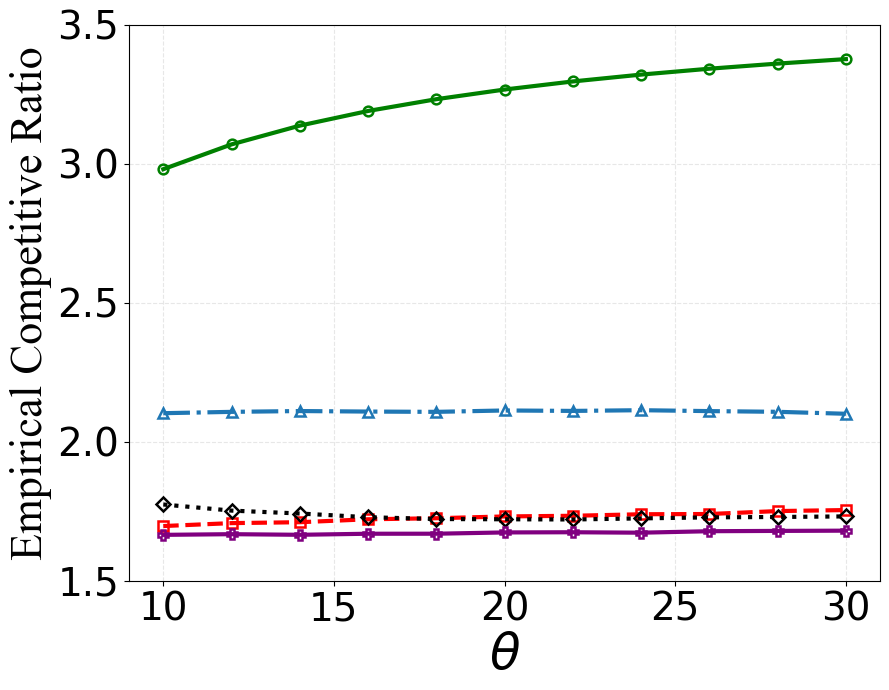

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt
def plot_combined_cr_vs_u_over_l(combined_df, save_path=None):
    df = combined_df.copy()

    alg_order = ["FCFS", "OPS", "OPS*", "D-OPS", "D-OPS*"]
    style_map = {
        "FCFS": {"marker": "o", "linestyle": "-", "linewidth": 3, "color": "green"},
        "OPS": {"marker": "^", "linestyle": "-.", "linewidth": 3, "color": "#1f77b4"},
        "OPS*": {"marker": "s", "linestyle": "--", "linewidth": 3, "color": "red"},
        "D-OPS": {"marker": "D", "linestyle": ":", "linewidth": 3, "color": "black"},
        "D-OPS*": {"marker": "P", "linestyle": "-", "linewidth": 3, "color": "purple"},
    }

    plt.figure(figsize=(9, 7))

    for alg in alg_order:
        sub = df[df["algorithm"] == alg].sort_values("U_over_L")
        sub = sub[sub["U_over_L"] >= 10]
        if sub.empty:
            continue

        plt.plot(
            sub["U_over_L"],
            sub["avg_cr_over_loads"],
            label=alg,
            marker=style_map[alg]["marker"],
            linestyle=style_map[alg]["linestyle"],
            linewidth=style_map[alg]["linewidth"],
            markersize=7,
            markerfacecolor="none",
            markeredgewidth=1.8,
            color=style_map[alg]["color"],
        )

    plt.xlabel(r"$\theta$", fontsize=36, fontname="Times New Roman")
    plt.ylabel("Empirical Competitive Ratio", fontsize=32, fontname="Times New Roman")
    ticks = plt.gca().get_yticks()
    plt.yticks(
        [1.5, 2.0, 2.5, 3.0, 3.5],
        [f"{t:.1f}" for t in [1.5, 2.0, 2.5, 3.0, 3.5]],
        fontsize=28,
    )
    plt.grid(True, alpha=0.3, linestyle="--")
    # plt.xticks(sorted(df["U_over_L"].dropna().unique()), fontsize=18)
    plt.xticks([10, 15, 20, 25, 30], fontsize=28)
    # plt.yticks(fontsize=28)
    # plt.legend(fontsize=16, frameon=True, loc="best")
#     plt.legend(
#     loc='upper center',
#     bbox_to_anchor=(0.5, 1.15),  # move above plot
#     ncol=5,                      # number of algorithms
#     frameon=True,
#     fontsize=28
# )
    plt.tight_layout()

    if save_path is not None:
        out_dir = os.path.dirname(save_path)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved plot to:", save_path)

    plt.show()
combined_path = "ul_sweep_ml_only_stationwise/combined_avg_cr_vs_u_over_l_stationwise.csv"
combined_df = pd.read_csv(combined_path)
VALUE_MODE = "stationwise"
ML_OUT_ROOT = f"ul_sweep_ml_only_{VALUE_MODE}"
plot_combined_cr_vs_u_over_l(
    combined_df,
    save_path=os.path.join(ML_OUT_ROOT, f"combined_avg_cr_vs_u_over_l_{VALUE_MODE}_v2.pdf"),
)